In [ ]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "matplotlib"
])


0

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

ImportError: DLL load failed while importing _image: An Application Control policy has blocked this file.

In [1]:
import sys
print(sys.executable)

d:\Credit_Card_Fraud_Detection\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything working!")

Everything working!


In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1081)

In [10]:
df = df.drop_duplicates()

print("New shape:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

New shape: (283726, 31)
Remaining duplicates: 0


In [11]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [12]:
fraud_percentage = (df["Class"].value_counts()[1] / len(df)) * 100

print("Fraud percentage:", fraud_percentage)

Fraud percentage: 0.1667101358352777


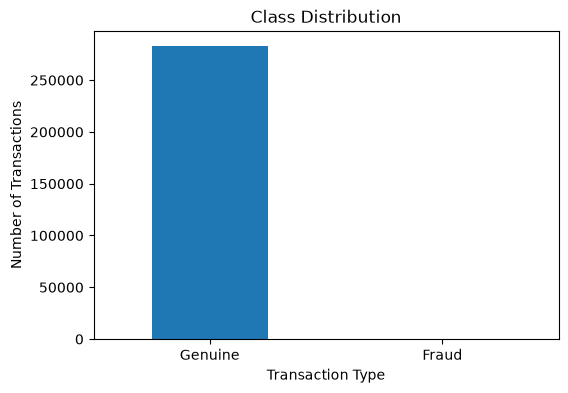

In [13]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Genuine", "Fraud"], rotation=0)

plt.show()

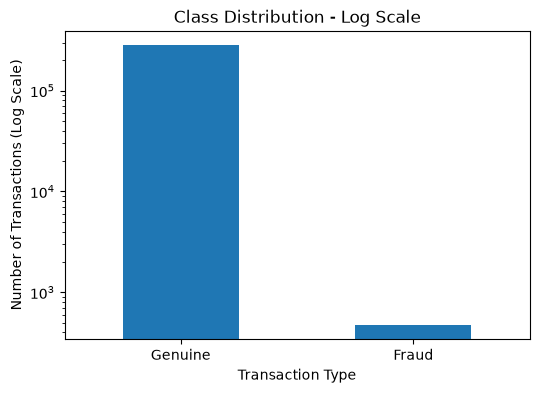

In [14]:
plt.figure(figsize=(6, 4))

class_counts.plot(kind="bar")

plt.yscale("log")

plt.title("Class Distribution - Log Scale")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions (Log Scale)")
plt.xticks([0, 1], ["Genuine", "Fraud"], rotation=0)

plt.show()

In [15]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


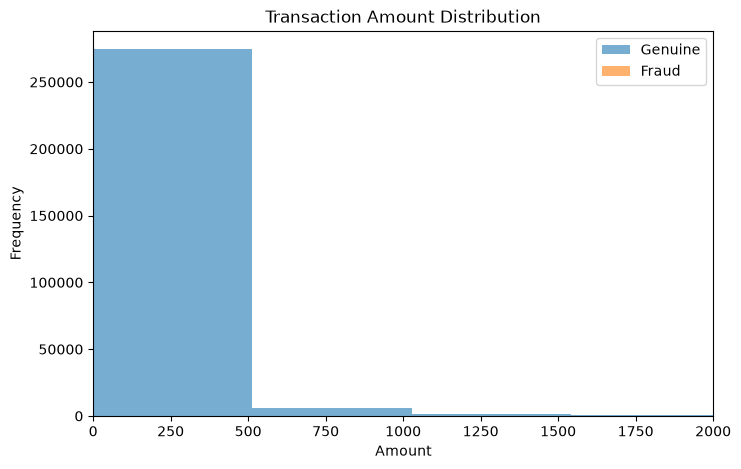

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Class"] == 0]["Amount"],
    bins=50,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    df[df["Class"] == 1]["Amount"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlim(0, 2000)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()

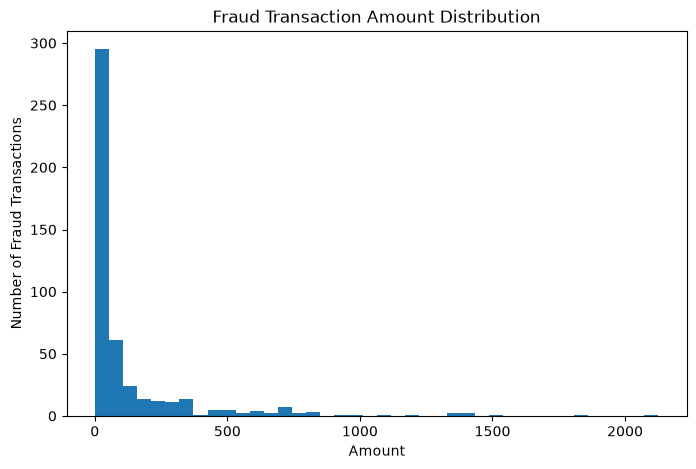

In [17]:
fraud_data = df[df["Class"] == 1]

plt.figure(figsize=(8, 5))

plt.hist(fraud_data["Amount"], bins=40)

plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Number of Fraud Transactions")

plt.show()

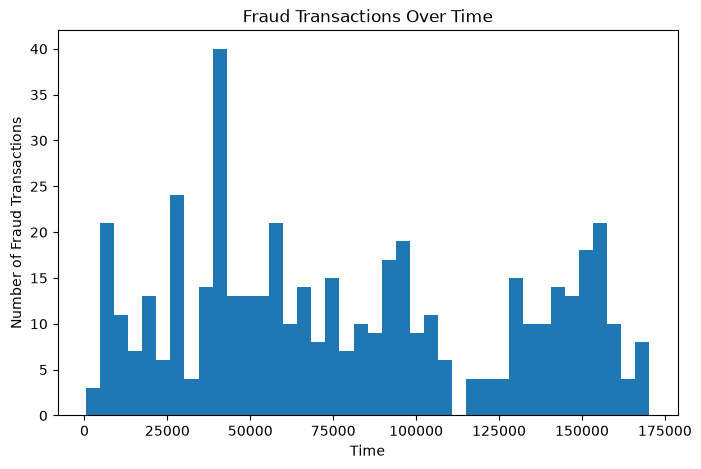

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(fraud_data["Time"], bins=40)

plt.title("Fraud Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Fraud Transactions")

plt.show()

In [19]:
#Target correlation check pannuvom
correlation = df.corr(numeric_only=True)["Class"].sort_values()

print(correlation)

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64


In [20]:
top_corr = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print(top_corr)

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


In [ ]:
# Find the top 10 features most strongly correlated with fraud

# Identifying Features Most Correlated with Fraud

top_corr = (
    df.corr(numeric_only=True)["Class"]   # Calculate correlation with target column
    .drop("Class")                        # Remove target itself
    .abs()                                # Consider correlation strength regardless of sign
    .sort_values(ascending=False)         # Sort from strongest to weakest
    .head(10)                             # Select top 10 features
)

print("Top 10 features correlated with fraud:")
print(top_corr)

Top 10 features correlated with fraud:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


In [22]:
# Save the cleaned dataset for further preprocessing and model training

df.to_csv("../data/processed/creditcard_clean.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [23]:
# Separate input features and target variable

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (283726, 30)
Target shape: (283726,)


In [1]:
import sys
print(sys.executable)

c:\Program Files\PythonEnvs\fraud-env\Scripts\python.exe


In [1]:
from sklearn.model_selection import train_test_split

print("scikit-learn working!")

scikit-learn working!


In [1]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Temporary features:", X_temp.shape)
print("Training target:", y_train.shape)
print("Temporary target:", y_temp.shape)

NameError: name 'X' is not defined